In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Загрузим уже обработанные в прошлом ДЗ данные!

In [2]:
df = pd.read_csv('processed_sigma.csv')
df = df.drop("Trip_ID", axis=1)

X = df.drop("Surge_Pricing_Type", axis=1)
y = df["Surge_Pricing_Type"]

In [4]:
df1 = df[['Trip_Distance', 'Customer_Since_Months', 'Life_Style_Index', 'Customer_Rating' ,'Cancellation_Last_1Month',"Surge_Pricing_Type"]]
df1

,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Surge_Pricing_Type
0,6.77,1.0,2.42769,3.90500,0,2
1,29.47,10.0,2.78245,3.45000,0,2
2,41.58,10.0,2.79805,3.50125,2,2
3,61.56,10.0,2.79805,3.45375,0,3
4,54.95,10.0,3.03453,3.40250,4,2
...,...,...,...,...,...,...
131657,11.72,1.0,2.74229,3.28500,0,3
131658,74.81,7.0,2.81059,0.44500,0,2
131659,40.17,10.0,2.99565,3.33625,0,2
131660,46.88,4.0,3.04744,4.15750,1,2


In [8]:
X = df1.drop("Surge_Pricing_Type", axis=1)
y = df1["Surge_Pricing_Type"]

In [5]:
df1.to_csv('data.csv', index=False)

### Principal component analysis (PCA)

**Задание 1.** Спроецируйте данные на двумерную плоскость, используя `PCA`. Другими словами, выделите первые две главные компоненты и изобразите данные в осях этих компонент. Не забудьте центрировать признаки перед применением метода. 

**Какую долю изначальной дисперсии (информации) содержат/объясняют в себе обе компоненты?** Для этого воспользуйтесь атрибутом `explained_variance_ratio_` у PCA-класса.

In [11]:
from sklearn.decomposition import PCA

### Your code is here
# Для разного количества компонент
X_centered = X - X.mean()

for n_components in [1, 2, 3, 4, 5]:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_centered)
    
    print(f"\nPCA с {n_components} компонентами:")
    print(f"Исходная размерность: {X.shape}")
    print(f"Размерность после PCA: {X_pca.shape}")
    print(f"Объясняемая дисперсия: {pca.explained_variance_ratio_}")
    print(f"Суммарная дисперсия: {np.sum(pca.explained_variance_ratio_):.6f}")
    print(f"Кумулятивная дисперсия: {np.cumsum(pca.explained_variance_ratio_)}")


PCA с 1 компонентами:
Исходная размерность: (131662, 5)
Размерность после PCA: (131662, 1)
Объясняемая дисперсия: [0.97828399]
Суммарная дисперсия: 0.978284
Кумулятивная дисперсия: [0.97828399]

PCA с 2 компонентами:
Исходная размерность: (131662, 5)
Размерность после PCA: (131662, 2)
Объясняемая дисперсия: [0.97828399 0.0186129 ]
Суммарная дисперсия: 0.996897
Кумулятивная дисперсия: [0.97828399 0.99689688]

PCA с 3 компонентами:
Исходная размерность: (131662, 5)
Размерность после PCA: (131662, 3)
Объясняемая дисперсия: [0.97828399 0.0186129  0.00161663]
Суммарная дисперсия: 0.998514
Кумулятивная дисперсия: [0.97828399 0.99689688 0.99851351]

PCA с 4 компонентами:
Исходная размерность: (131662, 5)
Размерность после PCA: (131662, 4)
Объясняемая дисперсия: [0.97828399 0.0186129  0.00161663 0.0014397 ]
Суммарная дисперсия: 0.999953
Кумулятивная дисперсия: [0.97828399 0.99689688 0.99851351 0.99995322]

PCA с 5 компонентами:
Исходная размерность: (131662, 5)
Размерность после PCA: (131662,

**Задание 2.** Изобразите heatmap корреляции изначальных признаков с новыми двумя главными компонентами. \
**Какие признаки коррелируют с первой компонентой? Какие со второй? В качестве порогового значения договоримся о корреляции >= 0.5 по абсолютному значению **


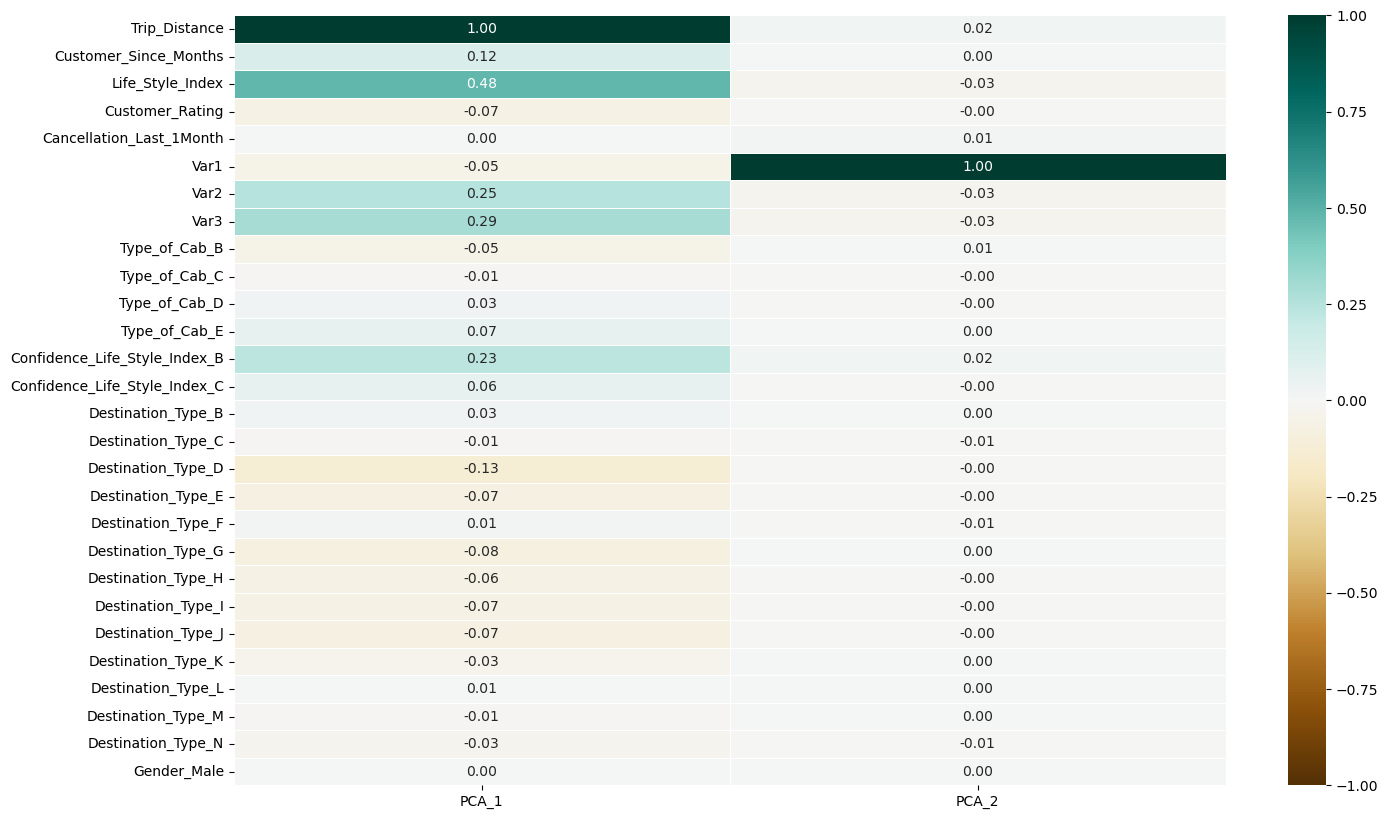

In [9]:
### Your code is here
import seaborn as sns

fig = plt.figure()

fig.set_size_inches(16, 10)

comp_1_corr = X.corrwith(PCA_df.PCA_1)
comp_2_corr = X.corrwith(PCA_df.PCA_2)
corrs = pd.concat((comp_1_corr, comp_2_corr), axis=1)
corrs.columns = ['PCA_1', 'PCA_2']

sns.heatmap(corrs,
           xticklabels=corrs.columns,
           yticklabels=corrs.index,
           cmap="BrBG",
           vmin=-1,
           vmax=1,
           annot=True,  
           fmt='.2f', 
           linewidths=0.5)
plt.show()

**Задание 3.** Изобразите двумерную проекцию данных с метками классов. Выделите третью главную компоненту и аналогично нарисуйте трехмерную проекцию с метками классов. \
**Какие признаки коррелируют с третьей компонентой?**

In [11]:
### Your code is here
PCA_full = np.concatenate((PCA_df, y.values.reshape(-1, 1)), axis=1)
PCA_full = pd.DataFrame(PCA_full, columns = ["PCA_1","PCA_2","Surge_Pricing_Type"])
PCA_full.head()



,PCA_1,PCA_2,Surge_Pricing_Type
0,-38.743132,-23.282634,2.0
1,-13.209252,-25.023815,2.0
2,-2.004910,-1.637085,2.0
3,17.178458,-0.907657,3.0
4,14.477389,-11.656752,2.0


<Axes: xlabel='PCA_1', ylabel='PCA_2'>

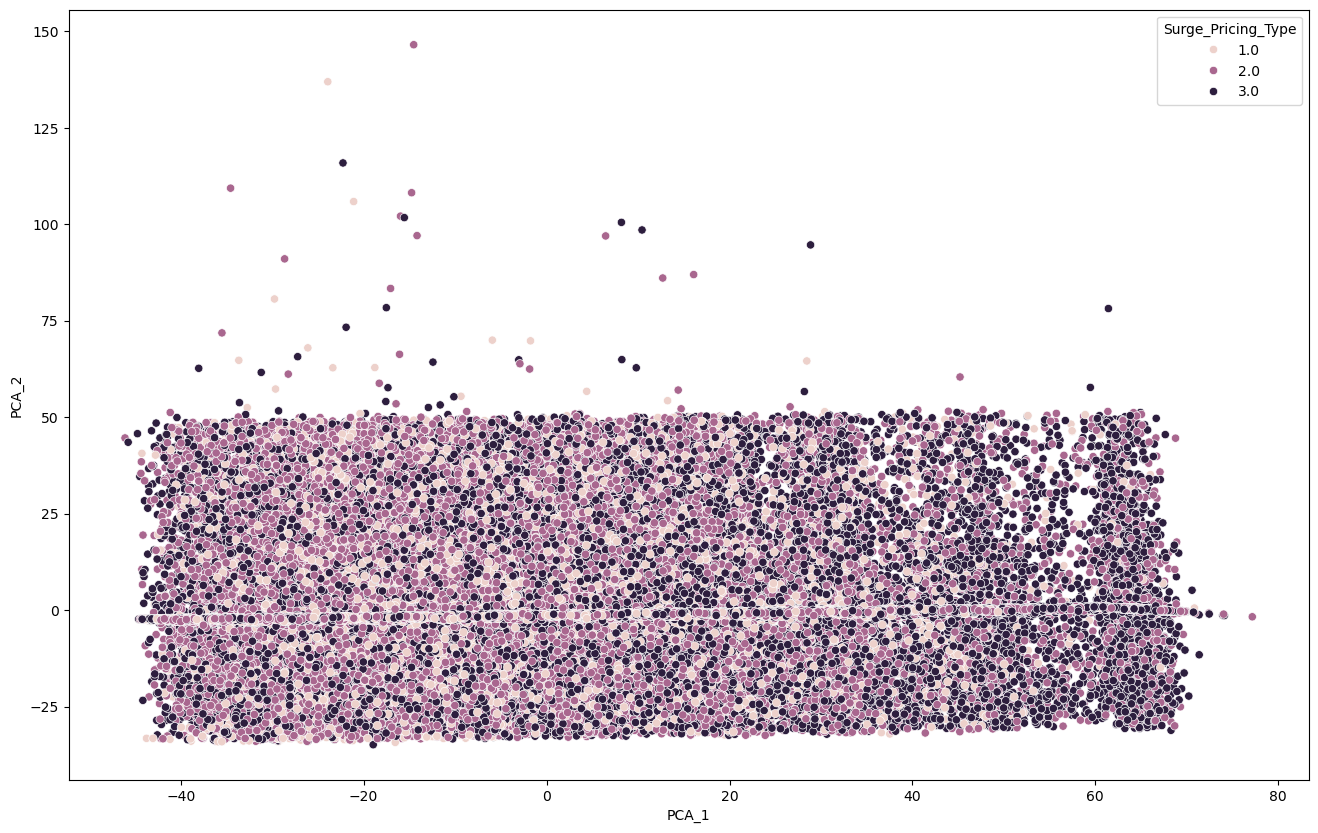

In [12]:
fig = plt.figure()
fig.set_size_inches(16, 10)

sns.scatterplot(data=PCA_full, x="PCA_1", y="PCA_2", hue="Surge_Pricing_Type")

Советуем еще и замерить попарные корреляции между главными компонентами! Это поможет в ответе на один из тестовых вопросов.

In [17]:
### Your code is here
PCA_full.corr()




,PCA_1,PCA_2,Surge_Pricing_Type
PCA_1,1.000000e+00,-6.698115e-17,0.131399
PCA_2,-6.698115e-17,1.000000e+00,-0.005755
Surge_Pricing_Type,1.313990e-01,-5.754804e-03,1.000000


In [15]:
pca = PCA(n_components=3)
PCA_3 = pca.fit_transform(X_centered)
PCA_3 = pd.DataFrame(PCA_3, columns =["PCA_1","PCA_2","PCA_3"])
PCA_3.head()

,PCA_1,PCA_2,PCA_3
0,-38.743132,-23.282634,-11.303274
1,-13.209252,-25.023815,5.664106
2,-2.004910,-1.637085,3.663032
3,17.178458,-0.907657,-3.191676
4,14.477389,-11.656752,22.999348


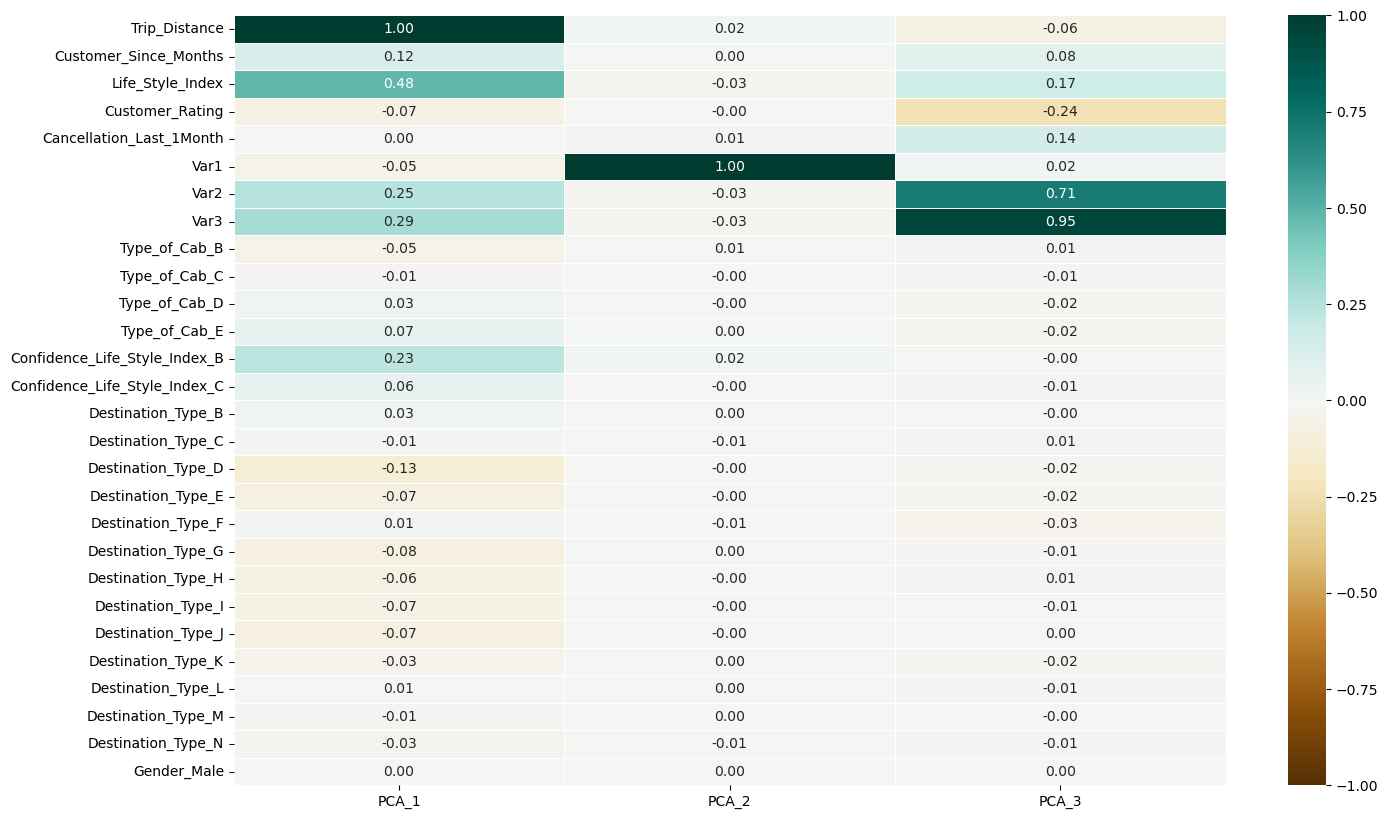

In [16]:
### Your code is here
import seaborn as sns

fig = plt.figure()

fig.set_size_inches(16, 10)

comp_1 = X.corrwith(PCA_3.PCA_1)
comp_2 = X.corrwith(PCA_3.PCA_2)
comp_3 = X.corrwith(PCA_3.PCA_3)
corrs_3 = pd.concat((comp_1, comp_2, comp_3), axis=1)
corrs_3.columns = ['PCA_1', 'PCA_2', 'PCA_3']

sns.heatmap(corrs_3,
           xticklabels=corrs_3.columns,
           yticklabels=corrs_3.index,
           cmap="BrBG",
           vmin=-1,
           vmax=1,
           annot=True,  
           fmt='.2f', 
           linewidths=0.5)
plt.show()

In [19]:
PCA_3_full = np.concatenate((PCA_3, y.values.reshape(-1, 1)), axis=1)
PCA_3_full = pd.DataFrame(PCA_3_full, columns = ["PCA_1","PCA_2","PCA_3", "Surge_Pricing_Type"])
PCA_3_full.head()

,PCA_1,PCA_2,PCA_3,Surge_Pricing_Type
0,-38.743132,-23.282634,-11.303274,2.0
1,-13.209252,-25.023815,5.664106,2.0
2,-2.004910,-1.637085,3.663032,2.0
3,17.178458,-0.907657,-3.191676,3.0
4,14.477389,-11.656752,22.999348,2.0


In [24]:
PCA_3_full["Surge_Pricing_Type"].value_counts()

Surge_Pricing_Type
2.0    56728
3.0    47720
1.0    27214
Name: count, dtype: int64

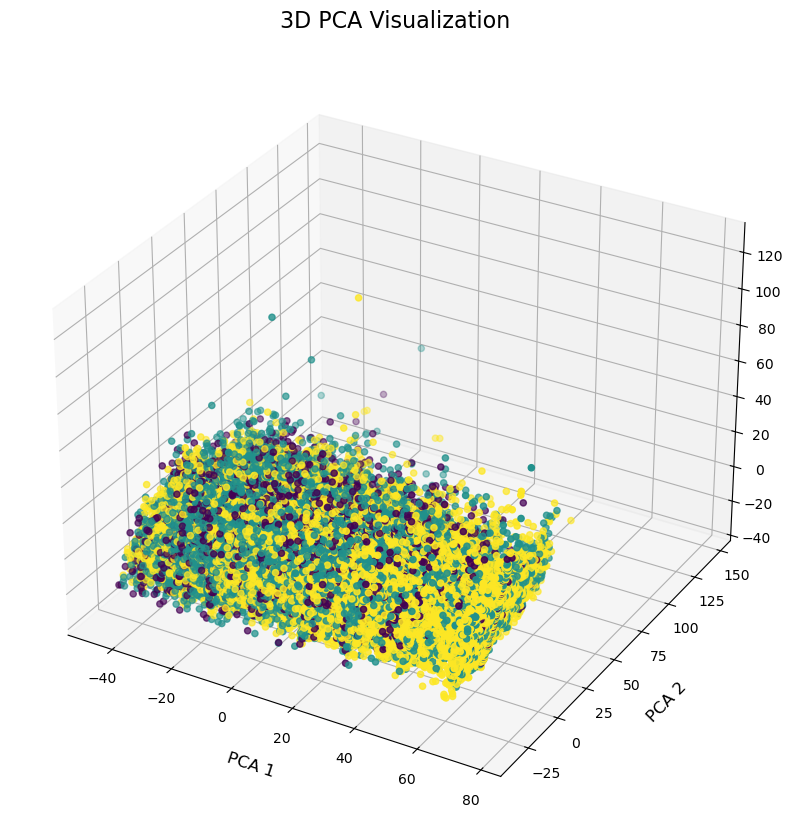

In [28]:
fig = plt.figure()
fig.set_size_inches(16, 10)

ax = plt.axes(projection='3d')

colors = PCA_3_full['Surge_Pricing_Type'].replace(['1', '2', '3'],
                                      ['green', 'red', 'blue'])

ax.scatter3D(PCA_3_full['PCA_1'], 
             PCA_3_full['PCA_2'],
             PCA_3_full['PCA_3'], 
             c=colors)
ax.set_xlabel('PCA 1', fontsize=12, labelpad=10)
ax.set_ylabel('PCA 2', fontsize=12, labelpad=10)
ax.set_zlabel('PCA 3', fontsize=12, labelpad=10)
ax.set_title('3D PCA Visualization', fontsize=16, pad=20)


plt.show()

**Задание 4.** Обучите логистическую регрессию на первых двух компонентах центрированных данных и подберите гиперпараметры. Обучите логистическую регрессию на центрированных данных и подберите гиперпараметры. **Сравните метрику accuracy и f1-score на тестовой выборке в двух моделях**.

P.S. для удобства, скорости и нормализации данных (понадобится, так как захотим повалидироваться на параметрах регуляризации) можно построить конструкцию Pipeline c 3 следующими степами: StandardScaler -> PCA -> LogisticRegression

In [29]:
np.random.seed(2022)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_centered, y, test_size=0.2, 
                                                    shuffle=True, random_state=2022)

In [31]:
### Your code is here

param_grid = {'model__penalty': ['l1', 'l2', 'elasticnet'],
              'model__C': [1e-5, 0.0001, 0.001, 0.01]}


In [35]:
pipe = Pipeline([('scaler',StandardScaler()),
                 ('pca',PCA(n_components=2)),
                 ('model', LogisticRegression())])

from sklearn.model_selection import PredefinedSplit

search = GridSearchCV(pipe, param_grid, cv=5)

In [36]:
search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           1      0.000     0.000     0.000      5372
           2      0.479     0.692     0.566     11349
           3      0.494     0.509     0.501      9612

    accuracy                          0.484     26333
   macro avg      0.324     0.401     0.356     26333
weighted avg      0.386     0.484     0.427     26333



In [39]:
pipe = Pipeline([('scaler',StandardScaler()),
                 ('model', LogisticRegression())])

search = GridSearchCV(pipe, param_grid, cv=5)
search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           1      0.737     0.538     0.622      5372
           2      0.637     0.826     0.719     11349
           3      0.735     0.588     0.653      9612

    accuracy                          0.680     26333
   macro avg      0.703     0.651     0.665     26333
weighted avg      0.693     0.680     0.675     26333



Кажется, достаточно сильно теряем в качестве! Может, добавить компонент?

**Задание 5.** Обучите модели логистической регресии на нескольких различных компонентах: [2, 4, 8, 16, 28]. **Нарисуйте графики зависимости accuracy, f1-score от количества компонент. Введите их значения через запятую**. При обучении используйте l2-регуляризацию, гиперпараметр C подбирайте по сетке. 


In [41]:
### Чтобы не заставлять вас писать похожий на предыдущий код,
### Написали функцию, которая будет обучать модель для
### произвольного числа n_components главных компонент.

def train_pca_i(n_components, X_train, y_train):
    pipe = Pipeline([('scaler', StandardScaler()), 
                     ('pca', PCA(n_components=n_components)),
                     ('model', LogisticRegression(penalty='l2', solver='saga',random_state=1))])
    
    param_grid = {'model__C': [0.0001, 0.001, 0.01, 0.1]}
    
    grid = GridSearchCV(pipe, param_grid, cv=5)
    grid.fit(X_train, y_train)
    
    report = classification_report(y_test, grid.predict(X_test), output_dict=True)
    return (report['accuracy'], 
            report['weighted avg']['f1-score'])

Accuracy: {2: 0.484, 4: 0.532, 8: 0.589, 16: 0.592, 28: 0.681}
F1-score: {2: 0.427, 4: 0.472, 8: 0.523, 16: 0.527, 28: 0.676}
CPU times: total: 3min 39s
Wall time: 53.6 s


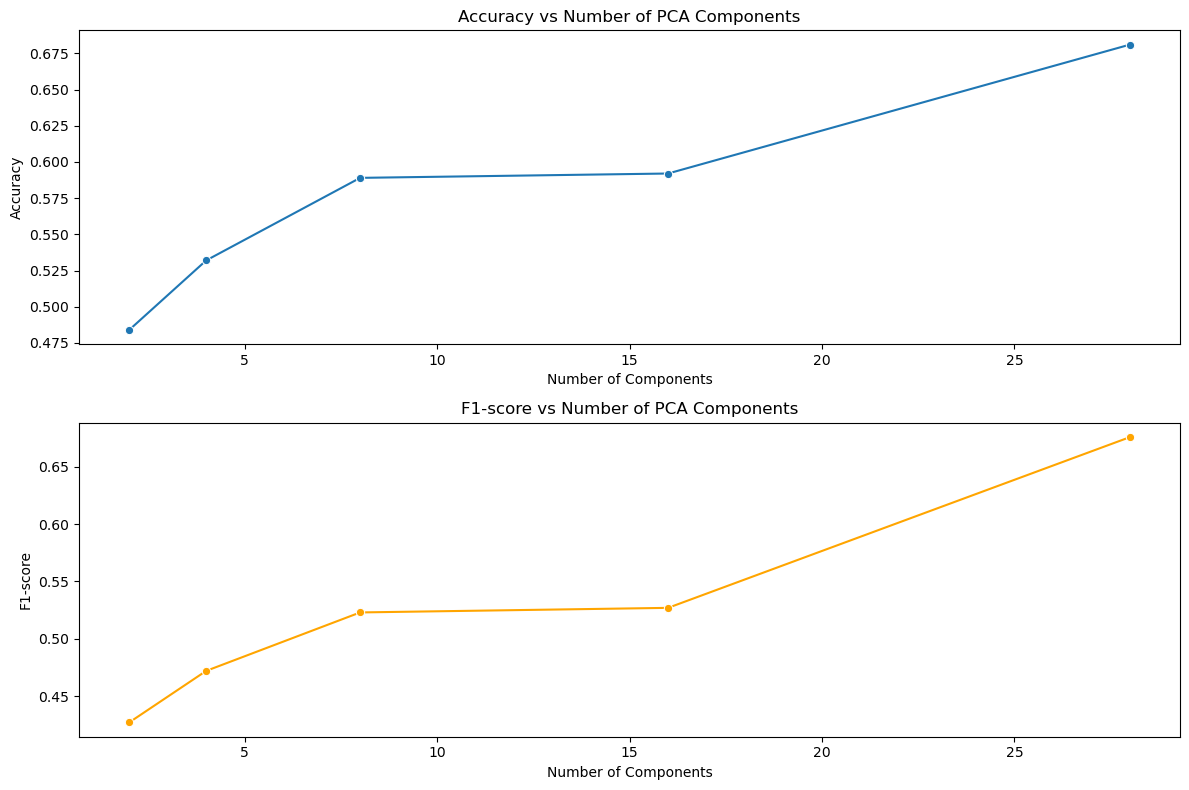

In [47]:
%%time
accuracy_dict, f1_score_dict = {}, {}
components_list = [2, 4, 8, 16, 28]
k=1
fig = plt.figure()
fig.set_size_inches(12, 8)

for n_components in components_list:
    
    ### Your code is here
    smth = train_pca_i(n_components, X_train, y_train)
    accuracy_dict[n_components] = round(smth[0], 3) 
    f1_score_dict[n_components] = round(smth[1], 3)
    
# График 1: Accuracy
ax1 = fig.add_subplot(2, 1, 1)
sns.lineplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of PCA Components')

# График 2: F1-score
ax2 = fig.add_subplot(2, 1, 2)
sns.lineplot(x=list(f1_score_dict.keys()), y=list(f1_score_dict.values()), marker='o', color='orange')
plt.xlabel('Number of Components')
plt.ylabel('F1-score')
plt.title('F1-score vs Number of PCA Components')

fig.tight_layout()

print("Accuracy:", accuracy_dict)
print("F1-score:", f1_score_dict)

Обычно, когда решается какая-то высокоразмерная предсказательная задача, где тысячи признаков, функция качества PCA моделей похожа на параболу ветвями вниз в зависимости от количества компонент (для совсем маленьких и больших n_component качество маленькое, при этом есть где-то промежуточное значение).

Как думаете, почему здесь у нас непрерывно растущие графики качества?

Может, изначальные признаки были слишком хороши?

### t-SNE

Напомним, что метод заключается в введении некоторых функций, основанных на расстоянии между признаками, которые измеряют близость объектов. Функций, как вы помните, две, и они заданы в исходном и новом пространствах соотвественно. Далее минимизируем дивергенцию Кульбака-Лейблера по координатaм в новом пространстве

**Задание 6.** Обучите t-sne c `n_components=2` на изначальных данных и визуализируйте результаты с учетом известных классов. 

P.S. если устанете ждать обучения TSNE, или упадет ошибка по типу oom, то можно сократить число объектов в датасете до, например, пары тысяч. Это и следующее задания никак проверяться системой не будут. Вам достаточно повторить упражнение с практики и получить какое-то более адекватное (по сравнению с PCA) изображение классов.

Text(0.5, 1.0, 'TSNE')

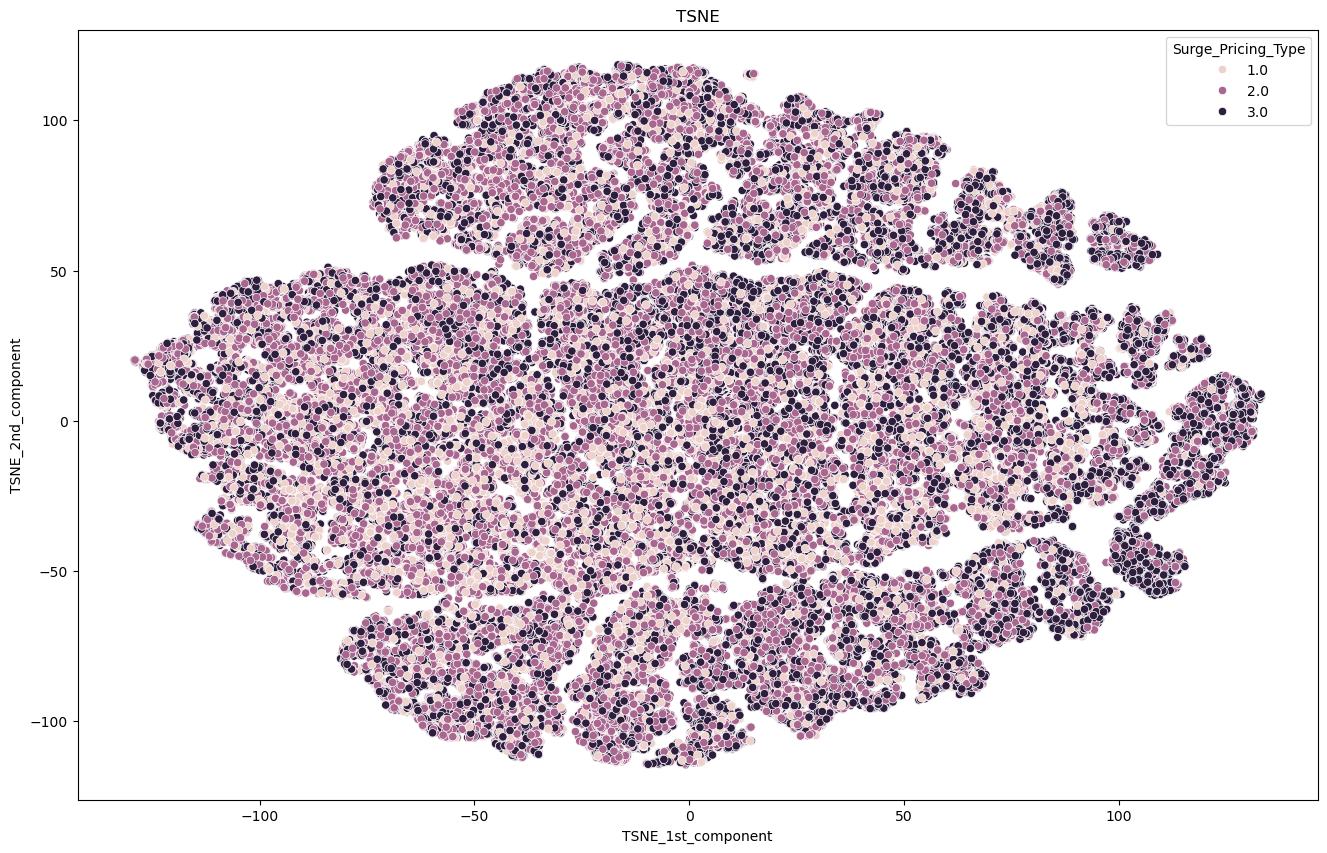

In [50]:
from sklearn.manifold import TSNE

### Your code is here
x_tsne = TSNE(n_components=2).fit_transform(X)
x_tsne = np.concatenate((x_tsne, y.values.reshape(-1,1)), axis=1)
x_tsne = pd.DataFrame(x_tsne, columns=["TSNE_1st_component","TSNE_2nd_component", "Surge_Pricing_Type"])

fig = plt.figure()
fig.set_size_inches(16, 10)

sns.scatterplot(data=x_tsne, x = "TSNE_1st_component", y = "TSNE_2nd_component", hue = "Surge_Pricing_Type")
plt.xlabel('TSNE_1st_component')
plt.ylabel('TSNE_2nd_component')
plt.title('TSNE')

**Задание 7.** Обучите t-sne с `n_components=3` на изначальных данных и визуализируйте результаты с учетом известных классов.

In [ ]:
%%time
### Your code is here
from sklearn.manifold import TSNE

### Your code is here
x_tsne = TSNE(n_components=3).fit_transform(X)
x_tsne = np.concatenate((x_tsne, y.values.reshape(-1,1)), axis=1)
x_tsne = pd.DataFrame(x_tsne, columns=["TSNE_1st_component","TSNE_2nd_component",'TSNE_3rd_component', "Surge_Pricing_Type"])

fig = plt.figure()
fig.set_size_inches(16, 10)

ax = plt.axes(projection='3d')
colors = X_tsne_3d['SEGMENT'].replace([1, 2, 3],
                                      ['green', 'red', 'blue'])

ax.scatter3D(X_tsne_3d['Tsne_1st_component'], 
             X_tsne_3d['Tsne_2nd_component'],
             X_tsne_3d['Tsne_3rd_component'], 
             c=colors)
ax.set_xlabel('TSNE_1st_component')
ax.set_ylabel('TSNE_2nd_component')
ax.set_zlabel('TSNE_3rd_component')
ax.set_title('3D TSNE Visualization')

plt.show()


Советуем обрезать датасет до маленького числа объектов (чтобы точки и их группки были хорошо различимы) и поиграться с гиперпараметрами класса Tsne! Обычно такая "игра" может привести к куда более красивым результатам по сравнению с теми, что получены с дефолтными настройками!